# Ames House Price Prediction

Quy trình machine learning sạch để đưa lên GitHub: tách test trước, loại outlier chỉ trên train, preprocessing trong pipeline, chọn model bằng 5-fold CV và chỉ đánh giá test một lần.

## 1. Thư viện và cấu hình

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
RANDOM_STATE=42
TEST_SIZE=0.20
CV_FOLDS=5

## 2. Đọc và kiểm tra dữ liệu

In [2]:
def locate_data():
    for p in [Path('../data/train.csv'), Path('data/train.csv')]:
        if p.exists(): return p.resolve()
    raise FileNotFoundError('Đặt train.csv trong thư mục data/.')

DATA_PATH=locate_data()
df=pd.read_csv(DATA_PATH,index_col='Id')
print('Shape:',df.shape)
print('Duplicates:',df.duplicated().sum())
print(df['SalePrice'].describe())
df.head()

Shape: (1460, 80)
Duplicates: 0
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. EDA ngắn gọn

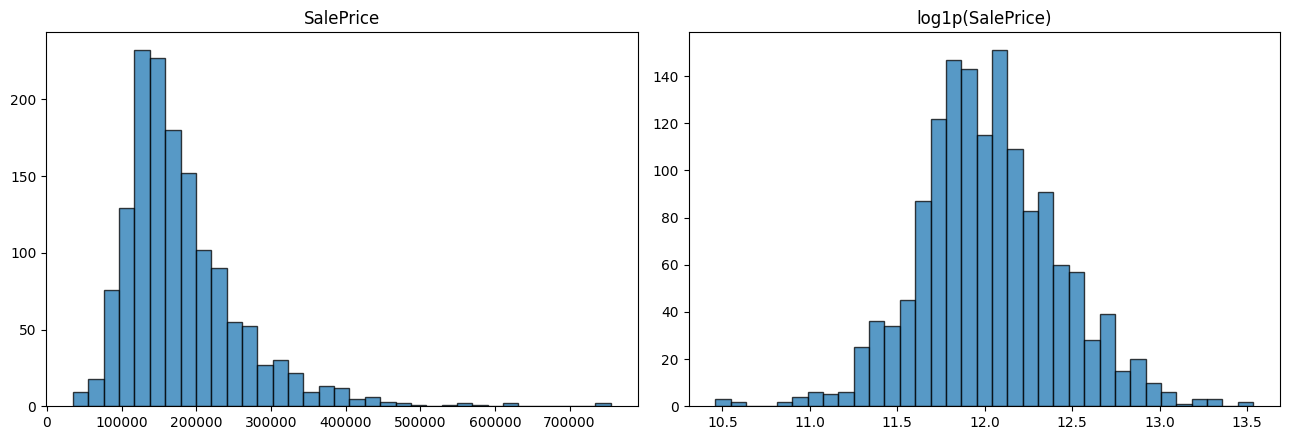

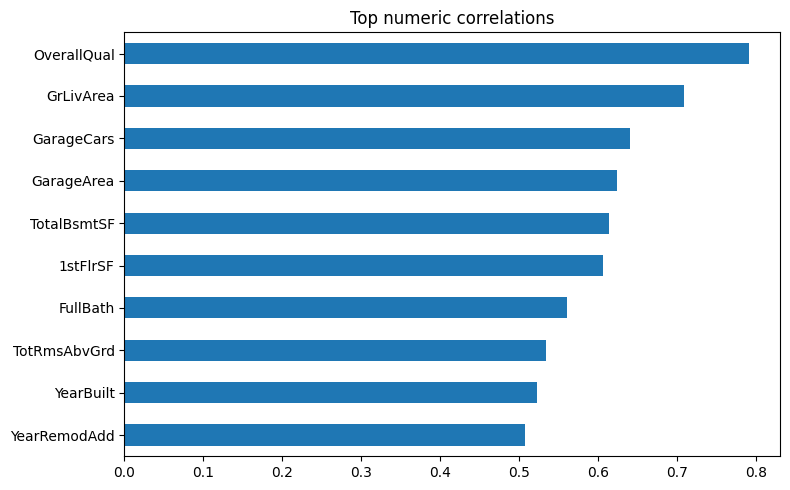

,correlation
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


In [3]:
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ax[0].hist(df['SalePrice'],bins=35,edgecolor='black',alpha=.75)
ax[0].set_title('SalePrice')
ax[1].hist(np.log1p(df['SalePrice']),bins=35,edgecolor='black',alpha=.75)
ax[1].set_title('log1p(SalePrice)')
plt.tight_layout(); plt.show()

corr=(df.select_dtypes('number').corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False).head(10))
corr.sort_values().plot(kind='barh',figsize=(8,5),title='Top numeric correlations')
plt.tight_layout(); plt.show()
corr.to_frame('correlation')

## 4. Tách train/test trước khi xử lý dựa trên target

In [4]:
X_raw=df.drop(columns='SalePrice')
y_raw=df['SalePrice'].copy()
X_train_raw,X_test_raw,y_train,y_test=train_test_split(X_raw,y_raw,test_size=TEST_SIZE,random_state=RANDOM_STATE)
mask=(X_train_raw['GrLivArea']>4000)&(y_train<300000)
print('Outliers removed from train:',int(mask.sum()))
X_train_raw=X_train_raw.loc[~mask].copy()
y_train=y_train.loc[~mask].copy()
print('Train:',X_train_raw.shape,'Test:',X_test_raw.shape)

Outliers removed from train: 2
Train: (1166, 79) Test: (292, 79)


## 5. Làm sạch xác định và tạo đặc trưng

In [5]:
DROP_COLS=['PoolQC','MiscFeature','Alley','Fence']
NONE_COLS=['FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType']
ZERO_COLS=['GarageYrBlt','MasVnrArea']
QUALITY_COLS=['ExterQual','ExterCond','HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond','BsmtQual','BsmtCond']
QUALITY_MAP={'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5}

def clean_features(data):
    x=data.copy().drop(columns=DROP_COLS,errors='ignore')
    n=[c for c in NONE_COLS if c in x]; z=[c for c in ZERO_COLS if c in x]
    x[n]=x[n].fillna('None'); x[z]=x[z].fillna(0)
    for c in [c for c in QUALITY_COLS if c in x]: x[c]=x[c].map(QUALITY_MAP)
    x['HouseAge']=(x['YrSold']-x['YearBuilt']).clip(lower=0)
    x['RemodAge']=(x['YrSold']-x['YearRemodAdd']).clip(lower=0)
    x['TotalSF']=(x['TotalBsmtSF']+x['1stFlrSF']+x['2ndFlrSF']).clip(lower=0)
    x['TotalBath']=(x['FullBath']+.5*x['HalfBath']+x['BsmtFullBath']+.5*x['BsmtHalfBath']).clip(lower=0)
    x['TotalPorchSF']=(x['OpenPorchSF']+x['EnclosedPorch']+x['3SsnPorch']+x['ScreenPorch']).clip(lower=0)
    x['HasGarage']=(x['GarageArea']>0).astype(int)
    x['HasBsmt']=(x['TotalBsmtSF']>0).astype(int)
    x['HasFireplace']=(x['Fireplaces']>0).astype(int)
    return x

X_train=clean_features(X_train_raw); X_test=clean_features(X_test_raw)
assert list(X_train.columns)==list(X_test.columns)
print('Features:',X_train.shape[1])

Features: 83


## 6. Preprocessing và mô hình

In [6]:
num_cols=X_train.select_dtypes(include='number').columns.tolist()
cat_cols=X_train.select_dtypes(exclude='number').columns.tolist()
preprocessor=ColumnTransformer([
 ('num',Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',RobustScaler())]),num_cols),
 ('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),cat_cols)
])

def estimator(model):
    pipe=Pipeline([('preprocessor',preprocessor),('model',model)])
    return TransformedTargetRegressor(regressor=pipe,func=np.log1p,inverse_func=np.expm1,check_inverse=False)

cv=KFold(n_splits=CV_FOLDS,shuffle=True,random_state=RANDOM_STATE)
scoring={'rmse':'neg_root_mean_squared_error','mae':'neg_mean_absolute_error','r2':'r2'}
print('Numeric:',len(num_cols),'Categorical:',len(cat_cols))

Numeric: 53 Categorical: 30


## 7. Baseline bằng cross-validation

In [7]:
models={'Linear Regression':LinearRegression(),'Ridge':Ridge(alpha=1),'Lasso':Lasso(alpha=.001,max_iter=20000)}
rows=[]
for name,model in models.items():
    s=cross_validate(estimator(model),X_train,y_train,cv=cv,scoring=scoring,n_jobs=1,error_score='raise')
    rows.append({'Model':name,'CV_RMSE_Mean':-s['test_rmse'].mean(),'CV_RMSE_Std':s['test_rmse'].std(),'CV_MAE_Mean':-s['test_mae'].mean(),'CV_R2_Mean':s['test_r2'].mean()})
baseline=pd.DataFrame(rows).sort_values('CV_RMSE_Mean').reset_index(drop=True)
baseline

,Model,CV_RMSE_Mean,CV_RMSE_Std,CV_MAE_Mean,CV_R2_Mean
0,Lasso,19822.960268,1408.182387,13717.615606,0.933713
1,Ridge,20565.408398,1427.985891,14053.251521,0.928731
2,Linear Regression,23042.095195,2084.363259,15054.954459,0.910648


## 8. Tuning Ridge và Lasso

In [8]:
spaces={
 'Ridge':(estimator(Ridge()),{'regressor__model__alpha':[1,5,10,20,50]}),
 'Lasso':(estimator(Lasso(max_iter=20000)),{'regressor__model__alpha':[.0001,.0003,.001,.003,.01]})
}
searches={}
for name,(est,params) in spaces.items():
    gs=GridSearchCV(est,params,scoring=scoring,refit='rmse',cv=cv,n_jobs=1,error_score='raise')
    gs.fit(X_train,y_train); searches[name]=gs
    print(name,gs.best_params_,'CV RMSE:',f'${-gs.best_score_:,.2f}')

Ridge {'regressor__model__alpha': 10} CV RMSE: $19,734.29
Lasso {'regressor__model__alpha': 0.0003} CV RMSE: $19,629.33


## 9. Chọn model bằng CV

In [9]:
candidate_rows=[]
# Linear từ bảng baseline
lin=baseline[baseline['Model']=='Linear Regression'].iloc[0].to_dict(); candidate_rows.append(lin)
for name in ['Ridge','Lasso']:
    gs=searches[name]; i=gs.best_index_
    candidate_rows.append({'Model':name,'CV_RMSE_Mean':-gs.cv_results_['mean_test_rmse'][i],'CV_RMSE_Std':gs.cv_results_['std_test_rmse'][i],'CV_MAE_Mean':-gs.cv_results_['mean_test_mae'][i],'CV_R2_Mean':gs.cv_results_['mean_test_r2'][i]})
candidates=pd.DataFrame(candidate_rows).sort_values('CV_RMSE_Mean').reset_index(drop=True)
candidates

,Model,CV_RMSE_Mean,CV_RMSE_Std,CV_MAE_Mean,CV_R2_Mean
0,Lasso,19629.333516,1336.468383,13516.266537,0.935100
1,Ridge,19734.286589,1414.603614,13559.347760,0.934325
2,Linear Regression,23042.095195,2084.363259,15054.954459,0.910648


## 10. Fit model cuối và đánh giá test đúng một lần

In [10]:
best_name=candidates.loc[0,'Model']
final_models={'Linear Regression':estimator(LinearRegression()),'Ridge':searches['Ridge'].best_estimator_,'Lasso':searches['Lasso'].best_estimator_}
best_model=final_models[best_name]
best_model.fit(X_train,y_train)
pred=best_model.predict(X_test)
metrics={'model':best_name,'mae':mean_absolute_error(y_test,pred),'rmse':np.sqrt(mean_squared_error(y_test,pred)),'r2':r2_score(y_test,pred)}
print('Selected:',best_name)
print(f"Test MAE : ${metrics['mae']:,.2f}")
print(f"Test RMSE: ${metrics['rmse']:,.2f}")
print(f"Test R2  : {metrics['r2']:.4f}")

Selected: Lasso
Test MAE : $14,105.60
Test RMSE: $21,111.96
Test R2  : 0.9419


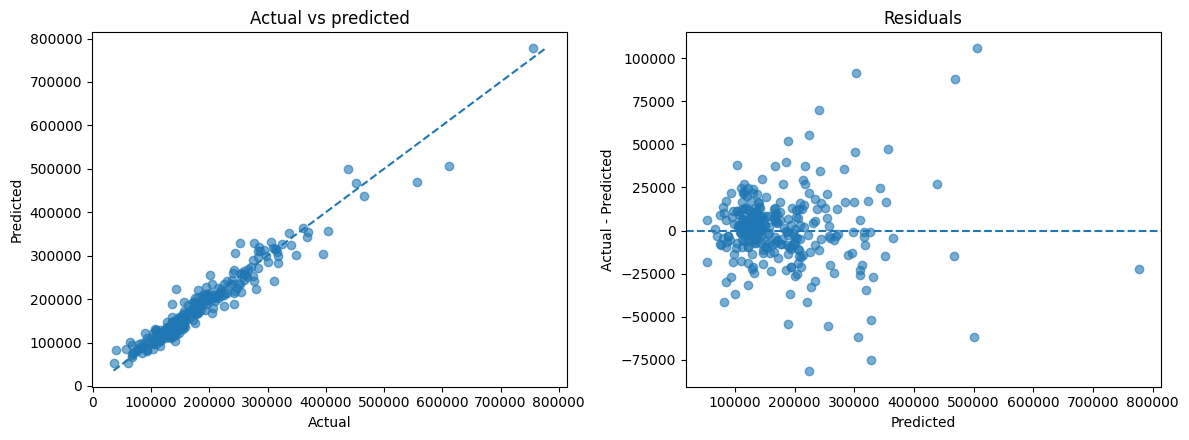

In [11]:
residual=y_test-pred
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
ax[0].scatter(y_test,pred,alpha=.6); lo=min(y_test.min(),pred.min()); hi=max(y_test.max(),pred.max()); ax[0].plot([lo,hi],[lo,hi],'--'); ax[0].set(title='Actual vs predicted',xlabel='Actual',ylabel='Predicted')
ax[1].scatter(pred,residual,alpha=.6); ax[1].axhline(0,ls='--'); ax[1].set(title='Residuals',xlabel='Predicted',ylabel='Actual - Predicted')
plt.tight_layout(); plt.show()

## 11. Lưu model và metadata

In [12]:
OUT=Path('../models'); OUT.mkdir(parents=True,exist_ok=True)
package={'model':best_model,'model_name':best_name,'raw_input_columns':X_raw.columns.tolist(),'engineered_input_columns':X_train.columns.tolist(),'feature_config':{'drop_cols':DROP_COLS,'none_cols':NONE_COLS,'zero_cols':ZERO_COLS,'quality_cols':QUALITY_COLS,'quality_map':QUALITY_MAP},'cv_results':candidates.to_dict(orient='records'),'test_metrics':metrics}
joblib.dump(package,OUT/'house_price_model.pkl')
with open(OUT/'metrics.json','w',encoding='utf-8') as f: json.dump({'selected_model':best_name,'cv_results':candidates.to_dict(orient='records'),'test_metrics':metrics},f,ensure_ascii=False,indent=2)
print('Saved:',(OUT/'house_price_model.pkl').resolve())

Saved: C:\Users\ADMIN\OneDrive\Desktop\DoAn2\models\house_price_model.pkl


## 12. Kết luận

- Test set không tham gia lựa chọn model.
- Preprocessing được fit riêng trong từng fold.
- Target transform nằm trong estimator nên CV RMSE, MAE và R² đều cùng thang USD.
- Ridge/Lasso được tuning bằng cùng một KFold.
- Model được lưu cùng metadata để thuận tiện triển khai Streamlit.